In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential


import os
import h5py
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras import layers, models
import h5py
import cv2

from sklearn.model_selection import RandomizedSearchCV
#from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import LabelEncoder



/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Simple DNN...
Simple DNN Accuracy: 0.7500

Training Deep DNN...
Deep DNN Accuracy: 0.8750

Training Dropout DNN...
Dropout DNN Accuracy: 0.8333

Training CNN Model...
CNN Model Accuracy: 0.7083

Training ANN Model...
ANN Model Accuracy: 0.8333


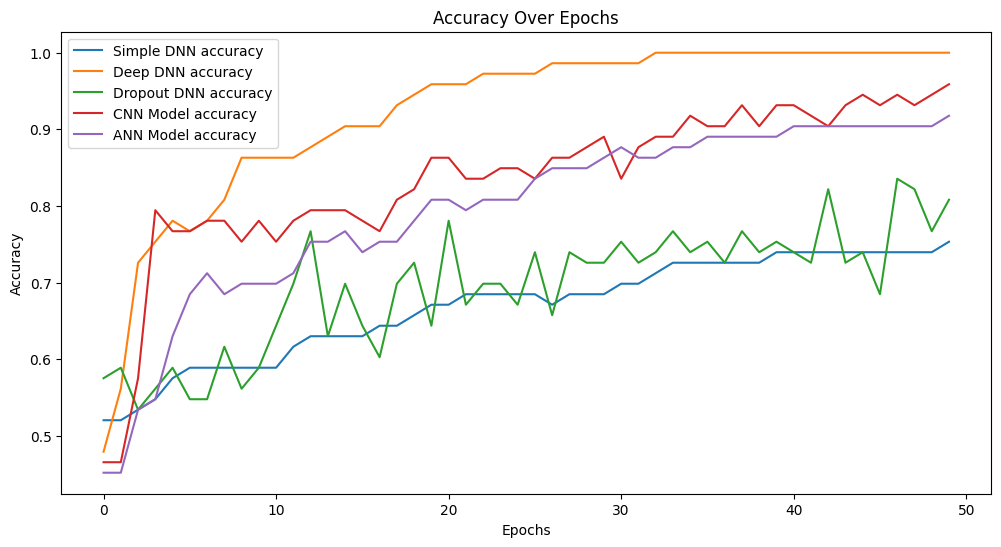

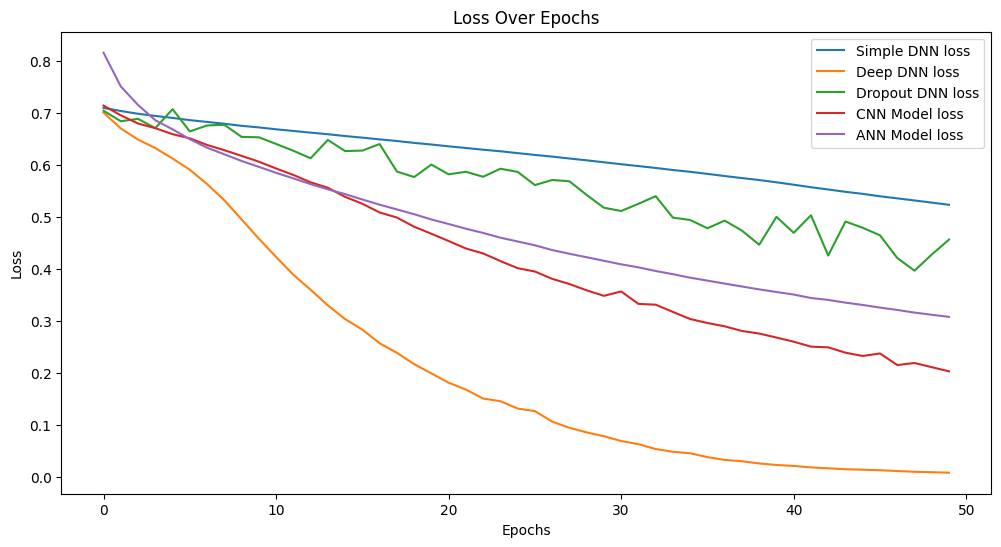


Confusion Matrix for Simple DNN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


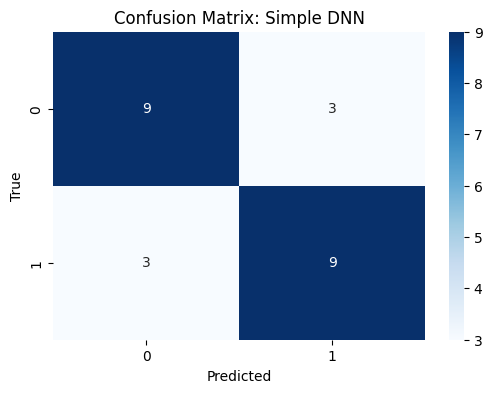


Confusion Matrix for Deep DNN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


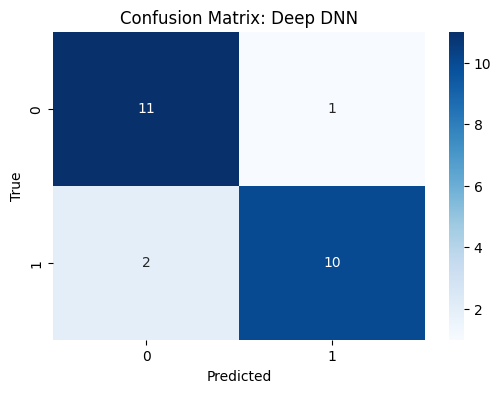


Confusion Matrix for Dropout DNN
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


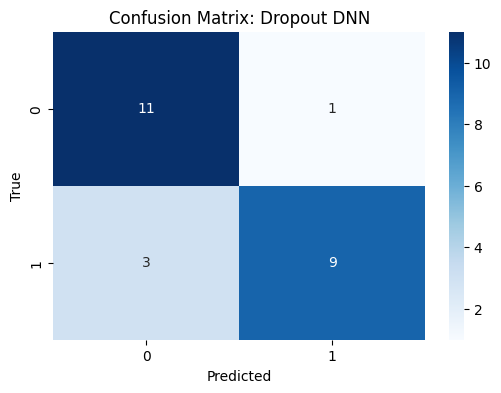


Confusion Matrix for CNN Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


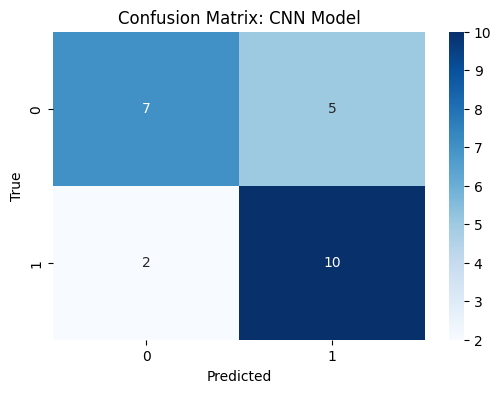


Confusion Matrix for ANN Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


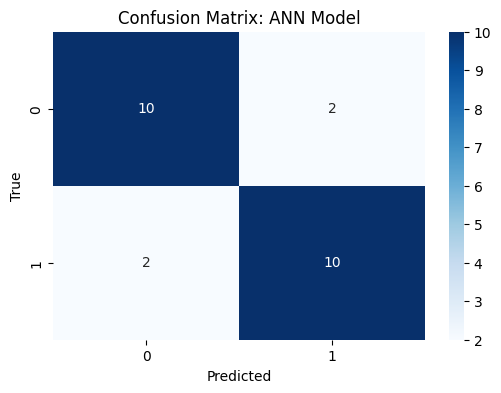

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Classification Report for Simple DNN
              precision    recall  f1-score   support

      Benign       0.75      0.75      0.75        12
   Malignant       0.75      0.75      0.75        12

    accuracy                           0.75        24
   macro avg       0.75      0.75      0.75        24
weighted avg       0.75      0.75      0.75        24

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Classification Report for Deep DNN
              precision    recall  f1-score   support

      Benign       0.85      0.92      0.88        12
   Malignant       0.91      0.83      0.87        12

    accuracy                           0.88        24
   macro avg       0.88      0.88      0.87        24
weighted avg       0.88      0.88      0.87        24

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Classification Report for Dropout DNN
              precision    recall  f1-score   support

      Benign       0.79      0.92      0.85        12
   Maligna

In [ ]:
#COIMBRA

# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"
df = pd.read_csv(url)

# Split the dataset into features and labels
X = df.drop("Classification", axis=1)
y = df["Classification"] - 1  # Adjust the labels to be 0 and 1

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data for CNN model (input shape for CNN must have an additional dimension)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Model 1: Simple Dense Neural Network (DNN)
def create_simple_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, input_dim=X_train.shape[1], activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model 2: Deep Neural Network (DNN)
def create_deep_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, input_dim=X_train.shape[1], activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model 3: Dropout-based DNN
def create_dropout_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, input_dim=X_train.shape[1], activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model 4: CNN-based Model (1D Convolutional Layers)
def create_cnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(32, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(64, kernel_size=2, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model 5: ANN Model
def create_ann_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, input_dim=X_train.shape[1], activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train and evaluate the models
models = {
    "Simple DNN": create_simple_model(),
    "Deep DNN": create_deep_model(),
    "Dropout DNN": create_dropout_model(),
    "CNN Model": create_cnn_model(),
    "ANN Model": create_ann_model()
}

history = {}
evaluation = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    if model_name == "CNN Model":
        history[model_name] = model.fit(X_train_cnn, y_train, epochs=50, validation_split=0.2, batch_size=16, verbose=0)
        evaluation[model_name] = model.evaluate(X_test_cnn, y_test, verbose=0)
    else:
        history[model_name] = model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=16, verbose=0)
        evaluation[model_name] = model.evaluate(X_test, y_test, verbose=0)
    print(f"{model_name} Accuracy: {evaluation[model_name][1]:.4f}")

# Evaluate all models
def plot_metrics(history, metric):
    plt.figure(figsize=(12, 6))
    for model_name, h in history.items():
        plt.plot(h.history[metric], label=f"{model_name} {metric}")
    plt.title(f"{metric.capitalize()} Over Epochs")
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.show()

# Plot Accuracy and Loss
plot_metrics(history, 'accuracy')
plot_metrics(history, 'loss')

# Confusion Matrix for each model
def plot_confusion_matrix(model, X_test, y_test, model_name, is_cnn=False):
    if is_cnn:
        y_pred = (model.predict(X_test) > 0.5).astype("int32")
    else:
        y_pred = (model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1])) > 0.5).astype("int32")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

for model_name, model in models.items():
    print(f"\nConfusion Matrix for {model_name}")
    if model_name == "CNN Model":
        plot_confusion_matrix(model, X_test_cnn, y_test, model_name, is_cnn=True)
    else:
        plot_confusion_matrix(model, X_test, y_test, model_name)

# Classification Report for each model
for model_name, model in models.items():
    if model_name == "CNN Model":
        y_pred = (model.predict(X_test_cnn) > 0.5).astype("int32")
    else:
        y_pred = (model.predict(X_test) > 0.5).astype("int32")
    print(f"\nClassification Report for {model_name}")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


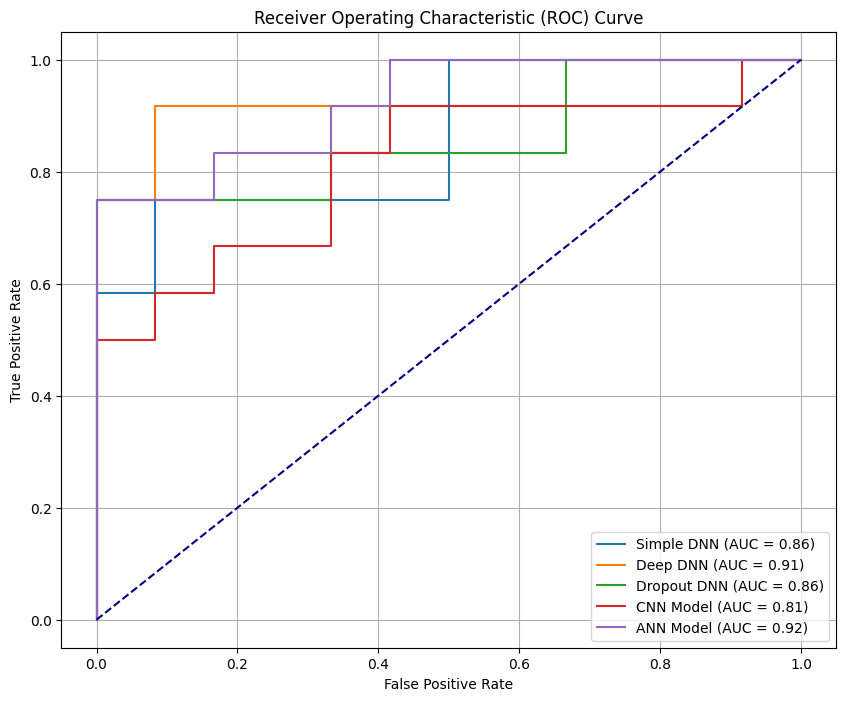

In [ ]:

from sklearn.metrics import roc_curve, auc

# Function to plot ROC and calculate AUC
def plot_roc_auc(models, X_tests, y_test, model_names, is_cnn_list):
    plt.figure(figsize=(10, 8))

    for model, X_test, model_name, is_cnn in zip(models, X_tests, model_names, is_cnn_list):
        # Predict probabilities
        if is_cnn:
            y_pred_proba = model.predict(X_test).ravel()
        else:
            y_pred_proba = model.predict(X_test).ravel()

        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

    # Plot the diagonal line
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')

    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

# Prepare models, test datasets, and their names
models = [models["Simple DNN"], models["Deep DNN"], models["Dropout DNN"], models["CNN Model"], models["ANN Model"]]
X_tests = [X_test, X_test, X_test, X_test_cnn, X_test]
model_names = ["Simple DNN", "Deep DNN", "Dropout DNN", "CNN Model", "ANN Model"]
is_cnn_list = [False, False, False, True, False]

# Plot ROC-AUC curves
plot_roc_auc(models, X_tests, y_test, model_names, is_cnn_list)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6290 - loss: 0.7118 - val_accuracy: 0.8462 - val_loss: 0.4182
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8356 - loss: 0.4304 - val_accuracy: 0.9121 - val_loss: 0.2882
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8620 - loss: 0.3102 - val_accuracy: 0.9341 - val_loss: 0.2288
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9029 - loss: 0.2372 - val_accuracy: 0.9451 - val_loss: 0.1930
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9275 - loss: 0.2292 - val_accuracy: 0.9560 - val_loss: 0.1688
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9203 - loss: 0.1774 - val_accuracy: 0.9670 - val_loss: 0.1502
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9519 - loss: 0.1489 - val_accuracy: 0.9670 - val_loss: 0.1376
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9624 - loss: 0.1460 - val_accuracy: 0.9670 - val_los

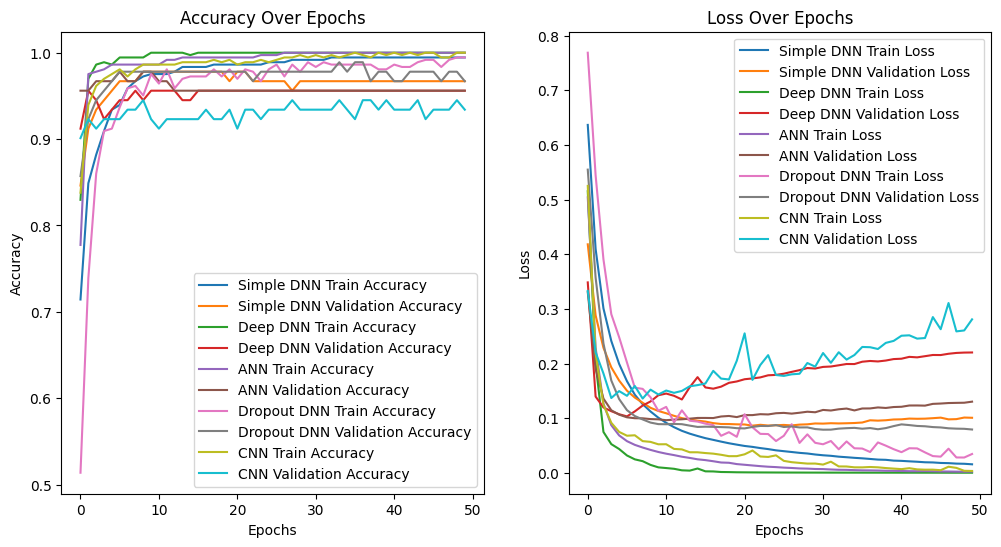

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


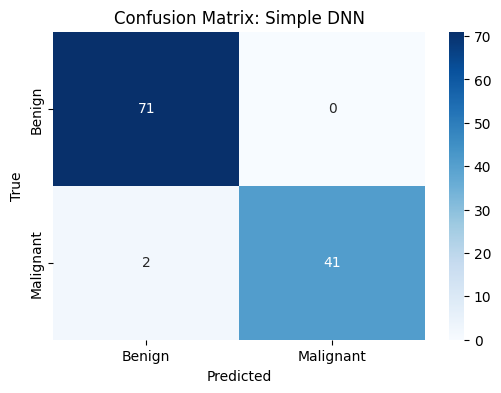


Classification Report for Simple DNN:

              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        71
   Malignant       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


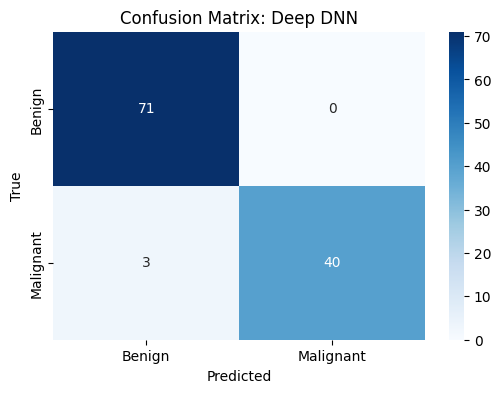


Classification Report for Deep DNN:

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        71
   Malignant       1.00      0.93      0.96        43

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


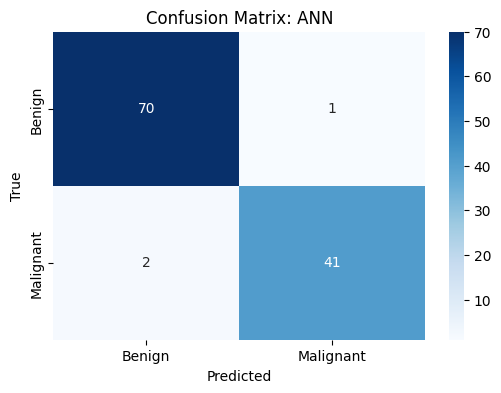


Classification Report for ANN:

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        71
   Malignant       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


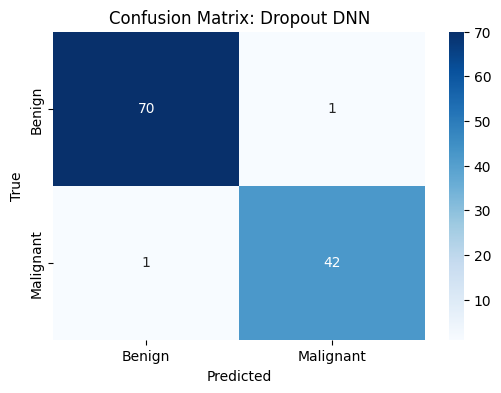


Classification Report for Dropout DNN:

              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99        71
   Malignant       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


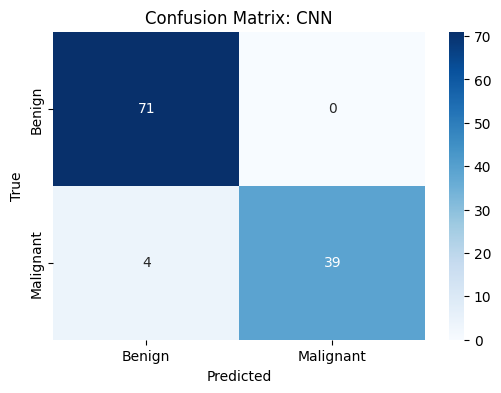


Classification Report for CNN:

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        71
   Malignant       1.00      0.91      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
#WISCONSIN 2

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
columns = ['ID', 'Diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
df = pd.read_csv(url, header=None, names=columns)
df.to_csv('breast_cancer_wisconsin.csv', index=False)

# Drop the ID column
df = df.drop("ID", axis=1)

# Convert the target 'Diagnosis' to binary labels: M=1 (Malignant), B=0 (Benign)
df['Diagnosis'] = df['Diagnosis'].apply(lambda x: 1 if x == 'M' else 0)

# Split the dataset into features and labels
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape the data for CNN model (1D CNN requires an additional dimension for input)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Model 1: Simple Dense Neural Network (DNN)
def create_simple_dnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, input_dim=X_train.shape[1], activation='relu'),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model 2: Deep Neural Network (DNN)
def create_deep_dnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, input_dim=X_train.shape[1], activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model 3: ANN Model
def create_ann_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, input_dim=X_train.shape[1], activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model 4: Dropout DNN
def create_dropout_dnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, input_dim=X_train.shape[1], activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model 5: CNN Model (1D Convolutional Layers)
def create_cnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv1D(32, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Conv1D(64, kernel_size=2, activation='relu'),
        tf.keras.layers.MaxPooling1D(pool_size=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Initialize and train all models
simple_dnn_model = create_simple_dnn_model()
deep_dnn_model = create_deep_dnn_model()
ann_model = create_ann_model()
dropout_dnn_model = create_dropout_dnn_model()
cnn_model = create_cnn_model()

# Train the simple DNN model
history_simple_dnn = simple_dnn_model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=16, verbose=1)

# Train the deep DNN
history_deep_dnn = deep_dnn_model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=16, verbose=1)

# Train the ANN model
history_ann = ann_model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=16, verbose=1)

# Train the Dropout DNN model
history_dropout_dnn = dropout_dnn_model.fit(X_train, y_train, epochs=50, validation_split=0.2, batch_size=16, verbose=1)

# Train the CNN model
history_cnn = cnn_model.fit(X_train_cnn, y_train, epochs=50, validation_split=0.2, batch_size=16, verbose=1)

# Evaluate all models on the test set
simple_dnn_loss, simple_dnn_accuracy = simple_dnn_model.evaluate(X_test, y_test, verbose=0)
deep_dnn_loss, deep_dnn_accuracy = deep_dnn_model.evaluate(X_test, y_test, verbose=0)
ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test, verbose=0)
dropout_dnn_loss, dropout_dnn_accuracy = dropout_dnn_model.evaluate(X_test, y_test, verbose=0)
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Simple DNN Model Test Accuracy: {simple_dnn_accuracy:.4f}")
print(f"Deep DNN Model Test Accuracy: {deep_dnn_accuracy:.4f}")
print(f"ANN Model Test Accuracy: {ann_accuracy:.4f}")
print(f"Dropout DNN Model Test Accuracy: {dropout_dnn_accuracy:.4f}")
print(f"CNN Model Test Accuracy: {cnn_accuracy:.4f}")

# Plot Accuracy and Loss for all models over epochs
def plot_history(histories, model_names):
    plt.figure(figsize=(12, 6))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    for history, model_name in zip(histories, model_names):
        plt.plot(history.history['accuracy'], label=f'{model_name} Train Accuracy')
        plt.plot(history.history['val_accuracy'], label=f'{model_name} Validation Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    for history, model_name in zip(histories, model_names):
        plt.plot(history.history['loss'], label=f'{model_name} Train Loss')
        plt.plot(history.history['val_loss'], label=f'{model_name} Validation Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Visualize training results
plot_history([history_simple_dnn, history_deep_dnn, history_ann, history_dropout_dnn, history_cnn],
             ["Simple DNN", "Deep DNN", "ANN", "Dropout DNN", "CNN"])

# Confusion Matrix and Classification Report for all models
def plot_confusion_matrix(model, X_test, y_test, model_name, is_cnn=False):
    if is_cnn:
        y_pred = (model.predict(X_test) > 0.5).astype("int32")
    else:
        y_pred = (model.predict(X_test) > 0.5).astype("int32")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Print classification report
    print(f"\nClassification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

# Plot confusion matrices and classification reports
plot_confusion_matrix(simple_dnn_model, X_test, y_test, "Simple DNN")
plot_confusion_matrix(deep_dnn_model, X_test, y_test, "Deep DNN")
plot_confusion_matrix(ann_model, X_test, y_test, "ANN")
plot_confusion_matrix(dropout_dnn_model, X_test, y_test, "Dropout DNN")
plot_confusion_matrix(cnn_model, X_test_cnn, y_test, "CNN", is_cnn=True)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


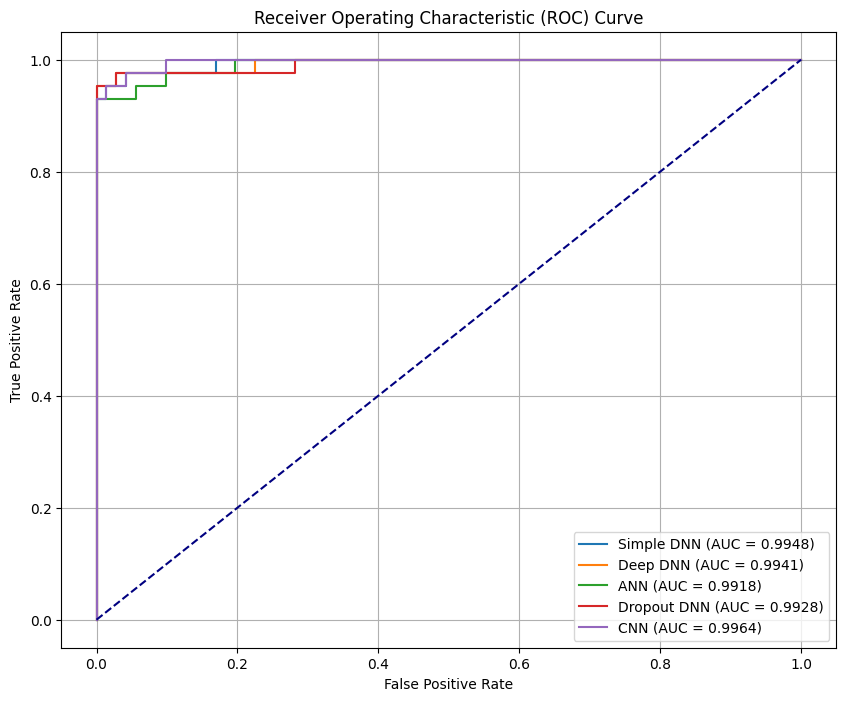

In [ ]:
from sklearn.metrics import roc_curve, auc

# Function to plot ROC and calculate AUC
def plot_roc_auc(models, X_tests, y_test, model_names, is_cnn_list):
    plt.figure(figsize=(10, 8))

    for model, X_test, model_name, is_cnn in zip(models, X_tests, model_names, is_cnn_list):
        # Predict probabilities
        if is_cnn:
            y_pred_proba = model.predict(X_test).ravel()
        else:
            y_pred_proba = model.predict(X_test).ravel()

        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

    # Plot the diagonal line
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')

    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

# Prepare models, test datasets, and their names
models = [simple_dnn_model, deep_dnn_model, ann_model, dropout_dnn_model, cnn_model]
X_tests = [X_test, X_test, X_test, X_test, X_test_cnn]
model_names = ["Simple DNN", "Deep DNN", "ANN", "Dropout DNN", "CNN"]
is_cnn_list = [False, False, False, False, True]

# Plot ROC-AUC curves
plot_roc_auc(models, X_tests, y_test, model_names, is_cnn_list)


In [ ]:

import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

#COIMBRA CV
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"
df = pd.read_csv(url)

# Split the dataset into features and labels
X = df.drop("Classification", axis=1)
y = df["Classification"] - 1  # Adjust the labels to be 0 and 1

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data for CNN model (input shape for CNN must have an additional dimension)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


def create_deep_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model



def kfold_cv_deep_nn(X, y, n_splits=5, epochs=50, batch_size=32):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    acc_scores = []
    auc_scores = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        print(f"Running fold {fold + 1}/{n_splits}")

        # Split data
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Scale inside the fold (NO leakage)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Build a fresh model for this fold
        model = create_deep_model(X_train.shape[1])

        # Train
        model.fit(
            X_train,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

        # Predict
        y_pred_prob = model.predict(X_test).ravel()
        y_pred = (y_pred_prob > 0.5).astype(int)

        # Metrics
        acc_scores.append(accuracy_score(y_test, y_pred))
        auc_scores.append(roc_auc_score(y_test, y_pred_prob))

        # Clean up TF session (important in Colab)
        tf.keras.backend.clear_session()

    return {
        "accuracy_mean": np.mean(acc_scores),
        "accuracy_std": np.std(acc_scores),
        "auc_mean": np.mean(auc_scores),
        "auc_std": np.std(auc_scores)
    }

results = kfold_cv_deep_nn(X.values, y.values, n_splits=5, epochs=50)
print(results)

Running fold 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Running fold 2/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Running fold 3/5


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Running fold 4/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Running fold 5/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
{'accuracy_mean': np.float64(0.7485507246376811), 'accuracy_std': np.float64(0.10549888484146895), 'auc_mean': np.float64(0.7771645021645022), 'auc_std': np.float64(0.11050294100448294)}


In [ ]:
#WISCONSIN 2

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
columns = ['ID', 'Diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
df = pd.read_csv(url, header=None, names=columns)
df.to_csv('breast_cancer_wisconsin.csv', index=False)

# Drop the ID column
df = df.drop("ID", axis=1)

# Convert the target 'Diagnosis' to binary labels: M=1 (Malignant), B=0 (Benign)
df['Diagnosis'] = df['Diagnosis'].apply(lambda x: 1 if x == 'M' else 0)

# Split the dataset into features and labels
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape the data for CNN model (1D CNN requires an additional dimension for input)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


def create_dropout_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
import tensorflow as tf

def kfold_cv_dropout_wdbc(X, y, n_splits=5, epochs=60, batch_size=16):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    acc_scores = []
    auc_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"Fold {fold + 1}/{n_splits}")

        # Split
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Scale INSIDE fold
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Build fresh dropout model
        model = create_dropout_model(X_train.shape[1])

        # Train
        model.fit(
            X_train,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0
        )

        # Predict
        y_prob = model.predict(X_test).ravel()
        y_pred = (y_prob > 0.5).astype(int)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        acc_scores.append(acc)
        auc_scores.append(auc)

        print(f"  Accuracy: {acc:.3f}, AUC: {auc:.3f}")

        # Important for Colab memory
        tf.keras.backend.clear_session()

    return {
        "accuracy_mean": np.mean(acc_scores),
        "accuracy_std": np.std(acc_scores),
        "auc_mean": np.mean(auc_scores),
        "auc_std": np.std(auc_scores)
    }
results = kfold_cv_dropout_wdbc(X.values, y.values)
print(results)


Fold 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
  Accuracy: 0.974, AUC: 0.991
Fold 2/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
  Accuracy: 0.974, AUC: 0.998
Fold 3/5


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
  Accuracy: 0.982, AUC: 0.984
Fold 4/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
  Accuracy: 0.956, AUC: 1.000
Fold 5/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
  Accuracy: 0.991, AUC: 0.999
{'accuracy_mean': np.float64(0.9754230709517155), 'accuracy_std': np.float64(0.011616237298934176), 'auc_mean': np.float64(0.9941987844378936), 'auc_std': np.float64(0.006016090116308088)}
